# **💳 German Credit Card Dataset : Classification Model**
A version of the famous German credit Dataset provided by UCI. The German Credit Dataset is a tabular dataset containing 1,000 individual loan applications collected by a German bank. Each row represents a single applicant, described by demographic, financial, and credit-history attributes, together with a credit-risk label.

We replaced the column names for more explicative names and replaced the codes provided in original dataset with more human-readable categories.

| # | Column Name | Data Type | Description |
|---|---|---|---|
| 1 | **Account_Balance** | Categorical | Status of existing checking account (e.g., balance levels) |
| 2 | **Duration** | Numerical | Credit duration in months |
| 3 | **Credit_History** | Categorical | Payment status of previous credits |
| 4 | **Purpose** | Categorical | Reason for the credit (e.g., car, furniture, education) |
| 5 | **Credit_Amount** | Numerical | Credit amount requested in DM (Deutsch Marks) |
| 6 | **Saving_Accounts_Bonds** | Categorical | Value of savings account/bonds |
| 7 | **Current_Employment_Length** | Categorical | Present employment duration with current employer |
| 8 | **Installment_Rate** | Numerical | Installment rate in percentage of disposable income |
| 9 | **MaritalStatusnGender** | Categorical | Combined personal status and sex of applicant |
| 10 | **Guarantors** | Categorical | Other debtors or co-signers/guarantors |
| 11 | **Duration_in_Current_Address** | Numerical | Length of time living in current residence |
| 12 | **Valuable_Asset** | Categorical | Applicant's most valuable asset / property owned |
| 13 | **Age** | Numerical | Age of applicant in years |
| 14 | **Other_Credit** | Categorical | Other installment credit plans (e.g., banks, stores) |
| 15 | **Housing** | Categorical | Housing situation (rent, own, or living for free) |
| 16 | **Existing_Credits** | Numerical | Number of active credits at this bank |
| 17 | **Job** | Categorical | Job classification/employment type |
| 18 | **Dependents** | Numerical | Number of people legally dependent on applicant |
| 19 | **Telephone** | Categorical | If a telephone is registered under the applicant's name |
| 20 | **ForeignWorker** | Categorical | Whether applicant is a foreign worker or not |
| 21 | **Good_Bad** *(Target)* | Binary | Credit risk status (1 = Good Credit, 2 = Bad Credit Risk) |

In [1]:
%pip install kagglehub xgboost


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Download and get the path of the latest dataset version
path = kagglehub.dataset_download("jumpingdino/german-credit-dataset")

# Load the file directly from the downloaded path into memory
data = pd.read_csv(f"{path}/german_credit_data.csv")
print(data.head())


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


        status_account  month_duration  \
0               < 0 DM               6   
1        0 to < 200 DM              48   
2  no checking account              12   
3               < 0 DM              42   
4               < 0 DM              24   

                                      credit_history              purpose  \
0  critical account/ other credits existing (not ...     radio/television   
1           existing credits paid back duly till now     radio/television   
2  critical account/ other credits existing (not ...            education   
3           existing credits paid back duly till now  furniture/equipment   
4                    delay in paying off in the past            car (new)   

   credit_amount               status_savings years_employment  \
0           1169  unknown/ no savings account       >= 7 years   
1           5951                     < 100 DM   1 to < 4 years   
2           2096                     < 100 DM   4 to < 7 years   
3           7882    

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status_account           1000 non-null   str  
 1   month_duration           1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   status_savings           1000 non-null   str  
 6   years_employment         1000 non-null   str  
 7   payment_to_income_ratio  1000 non-null   int64
 8   status_and_sex           1000 non-null   str  
 9   secondary_obligor        1000 non-null   str  
 10  residence_since          1000 non-null   int64
 11  collateral               1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  n_credits       

In [4]:
data.isnull().sum()

status_account             0
month_duration             0
credit_history             0
purpose                    0
credit_amount              0
status_savings             0
years_employment           0
payment_to_income_ratio    0
status_and_sex             0
secondary_obligor          0
residence_since            0
collateral                 0
age                        0
other_installment_plans    0
housing                    0
n_credits                  0
job                        0
n_guarantors               0
telephone                  0
is_foreign_worker          0
target                     0
dtype: int64

## Exploratory Data Analysis

In [5]:
data['job'].value_counts()

job
skilled employee/ official                             630
unskilled - resident                                   200
management/ self-employed/highly qualified employee    148
unemployed/ unskilled - non-resident                    22
Name: count, dtype: int64

In [6]:
data['purpose'].value_counts()

purpose
radio/television       280
car (new)              234
furniture/equipment    181
car (used)             103
business                97
education               50
repairs                 22
domestic appliances     12
others                  12
retraining               9
Name: count, dtype: int64

/var/folders/lf/wzrn2w4j7mq_hf01km30xn0c0000gn/T/ipykernel_21988/660611697.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="target", data=data, palette="Set2")


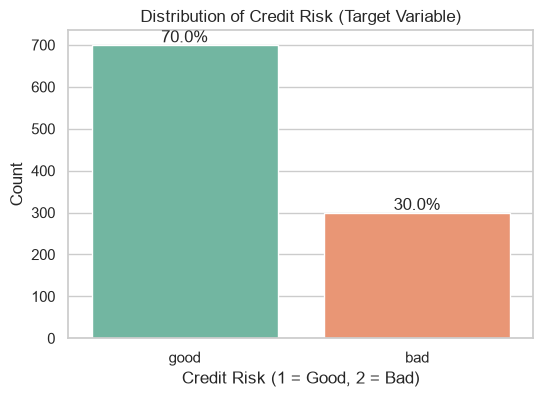

In [7]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="target", data=data, palette="Set2")
plt.title("Distribution of Credit Risk (Target Variable)")
plt.xlabel("Credit Risk (1 = Good, 2 = Bad)")
plt.ylabel("Count")

# Add percentage labels on top of bars
total = len(data)
for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
    )
plt.show()

=== Summary Statistics for Core Numerical Features ===
                 count      mean          std    min     25%     50%      75%  \
month_duration  1000.0    20.903    12.058814    4.0    12.0    18.0    24.00   
credit_amount   1000.0  3271.258  2822.736876  250.0  1365.5  2319.5  3972.25   
age             1000.0    35.546    11.375469   19.0    27.0    33.0    42.00   

                    max  
month_duration     72.0  
credit_amount   18424.0  
age                75.0  


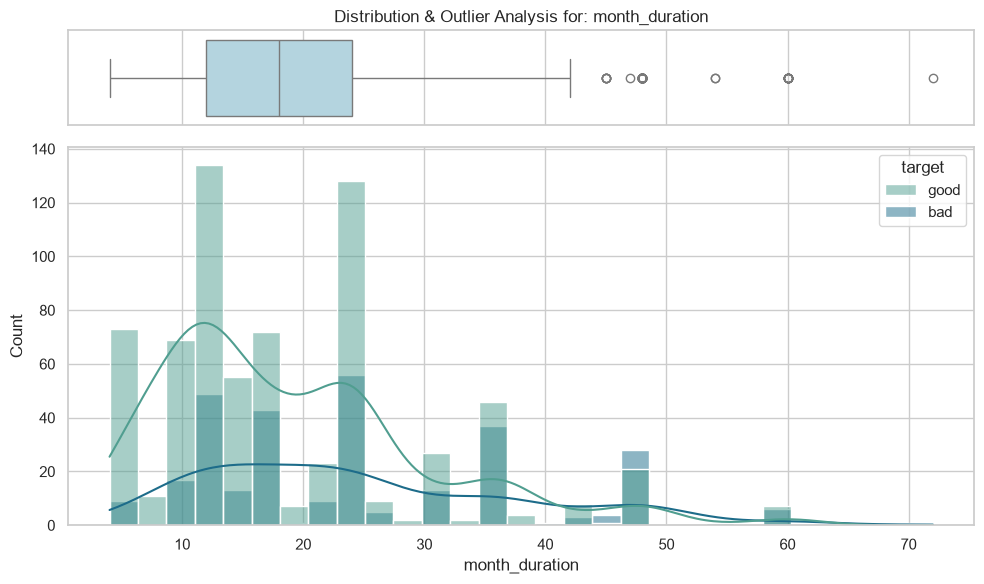

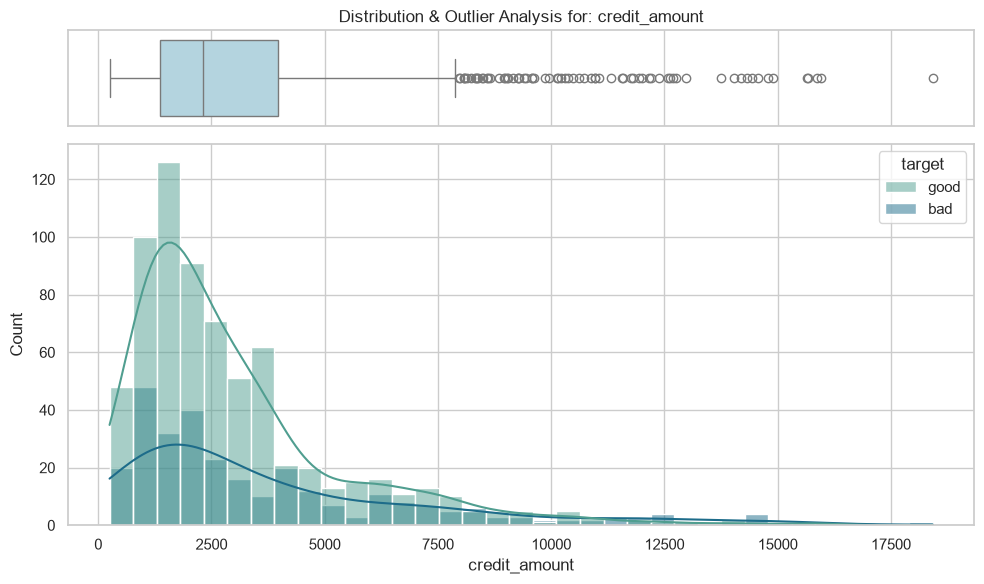

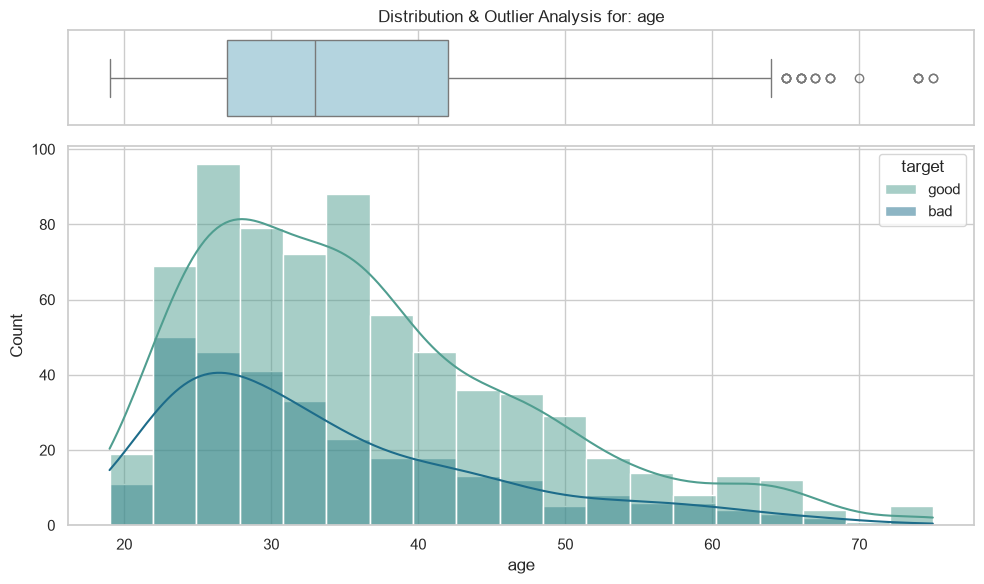

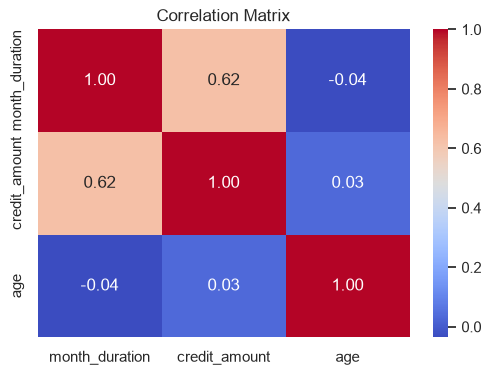

In [8]:
exact_num_cols = ["month_duration", "credit_amount", "age"]

print("=== Summary Statistics for Core Numerical Features ===")
print(data[exact_num_cols].describe().T)

# Boxplots and Histograms for major numerical indicators
for col in exact_num_cols:
    fig, (ax_box, ax_hist) = plt.subplots(
        2, sharex=True, gridspec_kw={"height_ratios": (0.2, 0.8)}
    )

    sns.boxplot(x=data[col], ax=ax_box, color="lightblue")
    sns.histplot(
        data=data, x=col, hue="target", kde=True, ax=ax_hist, palette="crest"
    )

    ax_box.set(xlabel="")
    ax_box.set_title(f"Distribution & Outlier Analysis for: {col}")
    plt.tight_layout()
    plt.show()

# Correlation Matrix for numeric variables
plt.figure(figsize=(6, 4))
sns.heatmap(data[exact_num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

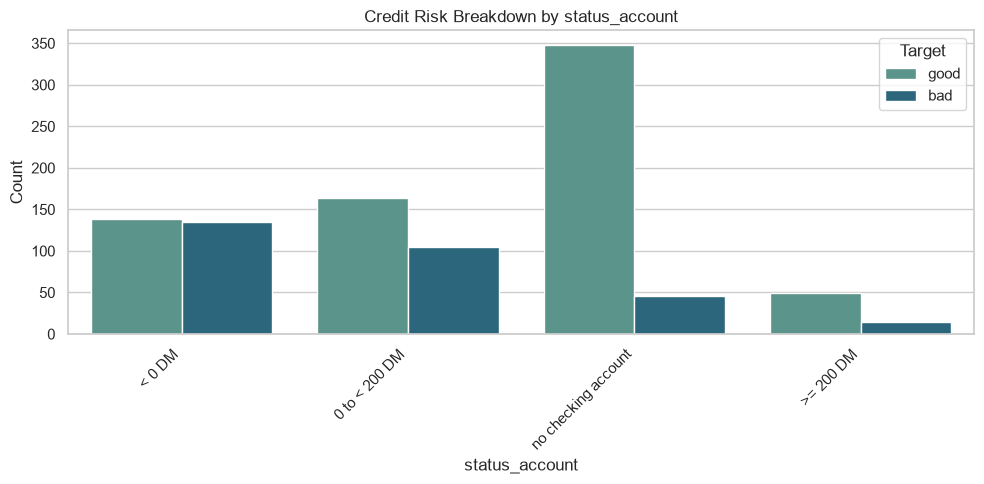

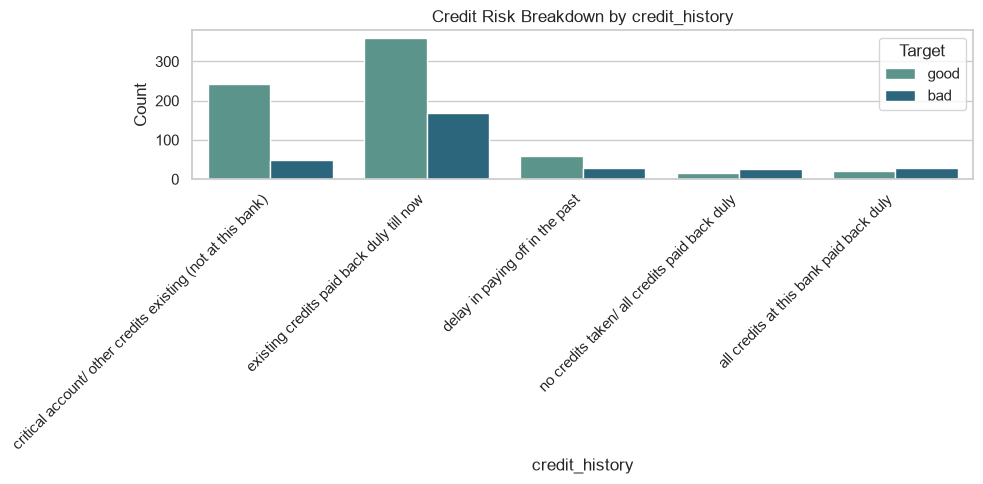

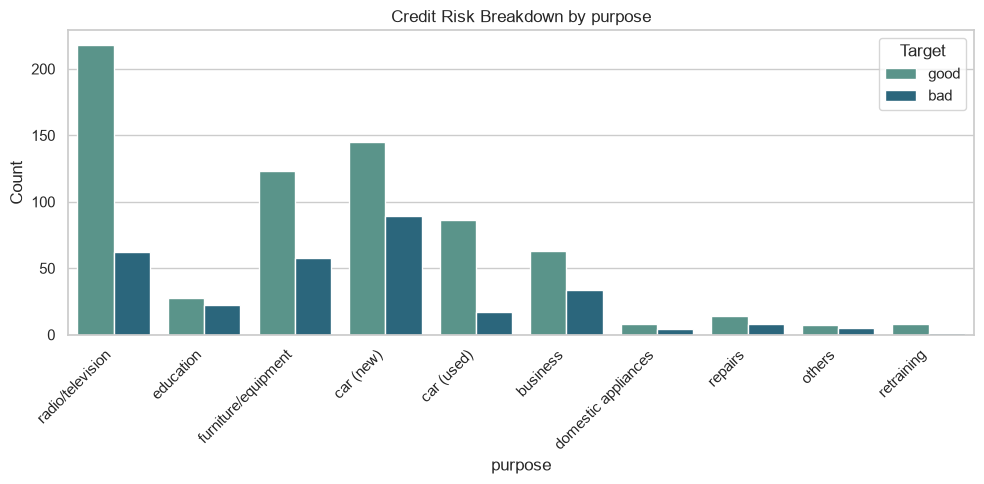

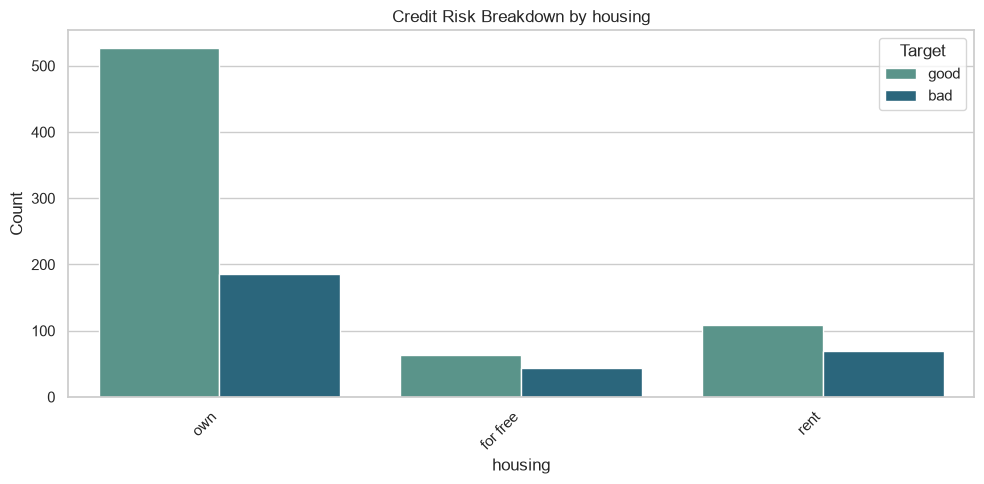

In [9]:
# Select high-variance categorical features from your list to check risk impact
key_cat_cols = ["status_account", "credit_history", "purpose", "housing"]

for col in key_cat_cols:
    if col in data.columns:
        plt.figure(figsize=(10, 5))
        sns.countplot(x=col, hue="target", data=data, palette="crest")
        plt.title(f"Credit Risk Breakdown by {col}")
        plt.xticks(rotation=45, ha="right")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.legend(title="Target")
        plt.tight_layout()
        plt.show()

## Feature Engineering

In [10]:
# Feature 1: Estimated Monthly Payment
data["estimated_monthly_payment"] = data["credit_amount"] / (
    data["month_duration"].replace(0, 1)
)

# Feature 2: Loan Duration to Age Ratio
data["loan_duration_to_age_ratio"] = data["month_duration"] / data["age"]

# Feature 3: Log Transform the heavily skewed credit amount
data["log_credit_amount"] = np.log1p(data["credit_amount"])

# Feature 4: High-Risk Purpose Indicator Flag
high_risk_purposes = ["education", "business"]
data["is_high_risk_purpose"] = (
    data["purpose"].astype(str).str.lower().isin(high_risk_purposes).astype(int)
)

# Feature 5: Recode Target from good/bad to 0/1 (0 = Good, 1 = Bad Credit Risk)
data["target"] = data["target"].map({"good": 0, "bad": 1})


## Classification and Ensemble/Forest Models

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier


In [12]:
X = data.drop(columns=["target", "credit_amount"])
y = data["target"]

numeric_features = [
    "month_duration",
    "age",
    "payment_to_income_ratio",
    "residence_since",
    "n_credits",
    "n_guarantors",
    "estimated_monthly_payment",
    "loan_duration_to_age_ratio",
    "log_credit_amount",
]

categorical_features = [
    "status_account",
    "credit_history",
    "purpose",
    "status_savings",
    "years_employment",
    "status_and_sex",
    "secondary_obligor",
    "collateral",
    "other_installment_plans",
    "housing",
    "job",
    "telephone",
    "is_foreign_worker",
    "is_high_risk_purpose",
]

# Stratified 80/20 split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric="logloss",
    ),
}

results = []

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_pred_proba = pipe.predict_proba(X_test)[:, 1]

    results.append(
        {
            "Model": name,
            "ROC-AUC Score": round(roc_auc_score(y_test, y_pred_proba), 4),
            "F1-Score": round(f1_score(y_test, y_pred), 4),
        }
    )

results_df = pd.DataFrame(results).sort_values(
    by="ROC-AUC Score", ascending=False
)
print(results_df.to_string(index=False))


              Model  ROC-AUC Score  F1-Score
Logistic Regression         0.8090    0.6250
      Random Forest         0.8042    0.5417
            XGBoost         0.7718    0.5688


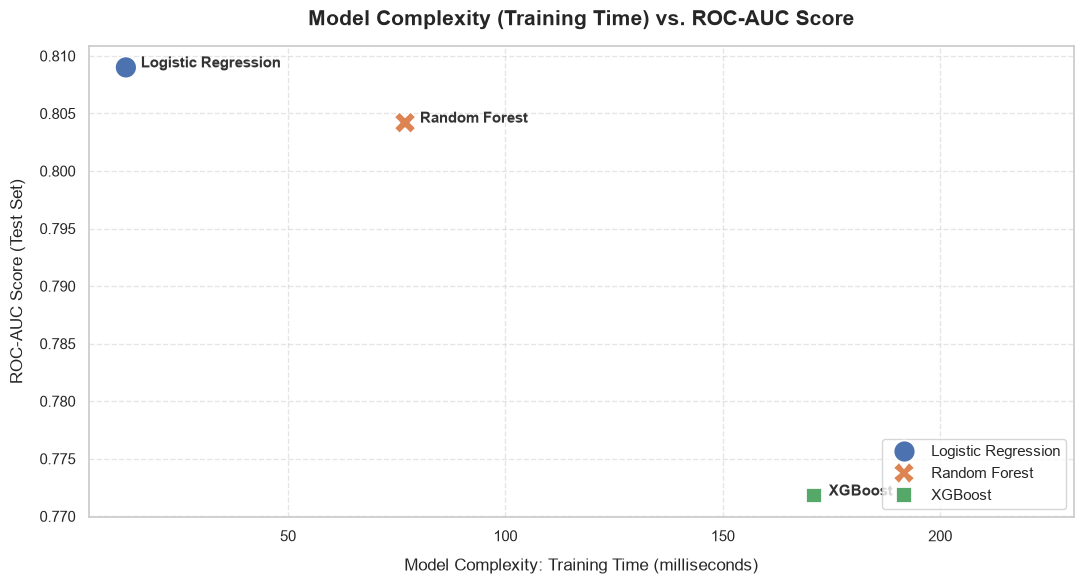

In [14]:
X_train_processed = preprocessor.fit_transform(X_train)

training_times = {}
for name, model in models.items():
    start_time = time.process_time()
    model.fit(X_train_processed, y_train)  # Re-running fit to capture execution time
    end_time = time.process_time()
    # Convert to milliseconds for a readable scale
    training_times[name] = (end_time - start_time) * 1000

# Map the calculated times back to your existing results_df
results_df["Training Time (ms)"] = results_df["Model"].map(training_times)


plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

# Scatter plot of the data points
sns.scatterplot(
    data=results_df,
    x="Training Time (ms)",
    y="ROC-AUC Score",
    hue="Model",
    style="Model",
    s=250,  # Large, readable markers
    palette="deep",
)


max_time = results_df["Training Time (ms)"].max()
for i in range(results_df.shape[0]):
    plt.text(
        x=results_df["Training Time (ms)"].iloc[i] + (max_time * 0.02),  # Soft visual offset to the right
        y=results_df["ROC-AUC Score"].iloc[i],
        s=results_df["Model"].iloc[i],
        fontdict=dict(color="black", alpha=0.8, size=11, weight="bold"),
    )


plt.title("Model Complexity (Training Time) vs. ROC-AUC Score", fontsize=15, pad=15, weight="bold")
plt.xlabel("Model Complexity: Training Time (milliseconds)", fontsize=12, labelpad=10)
plt.ylabel("ROC-AUC Score (Test Set)", fontsize=12, labelpad=10)
plt.grid(True, linestyle="--", alpha=0.5)

# Dynamically pad the X-axis limit so right-hand labels don't get cut off
plt.xlim(
    results_df["Training Time (ms)"].min() - (max_time * 0.05),
    max_time * 1.35,
)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()
